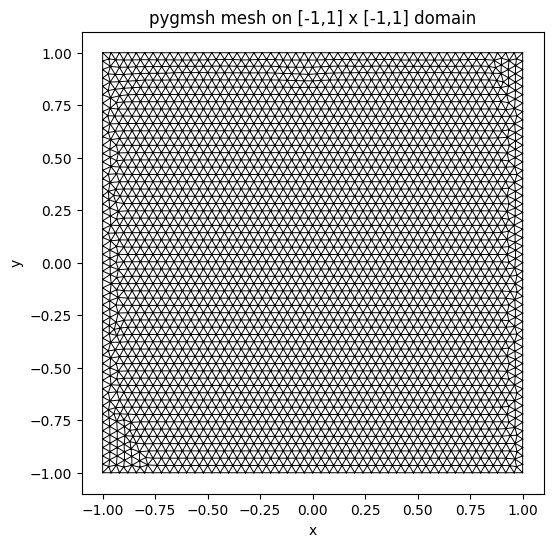

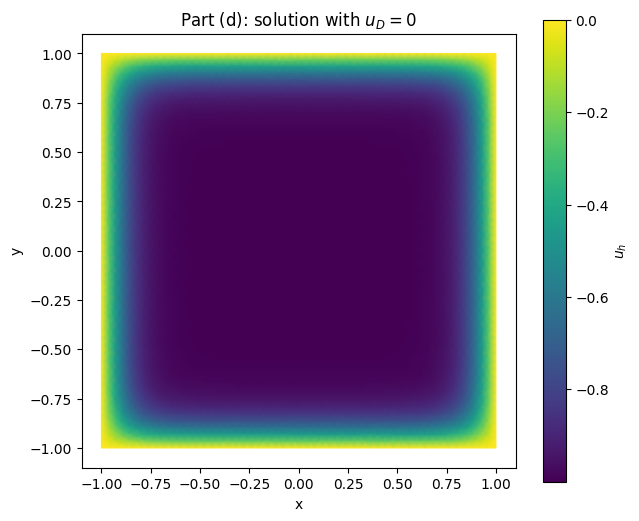

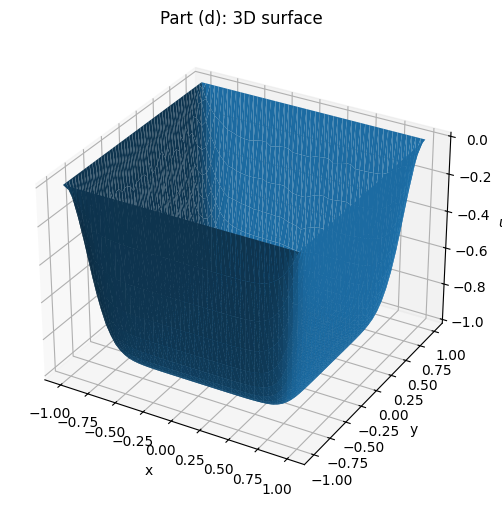

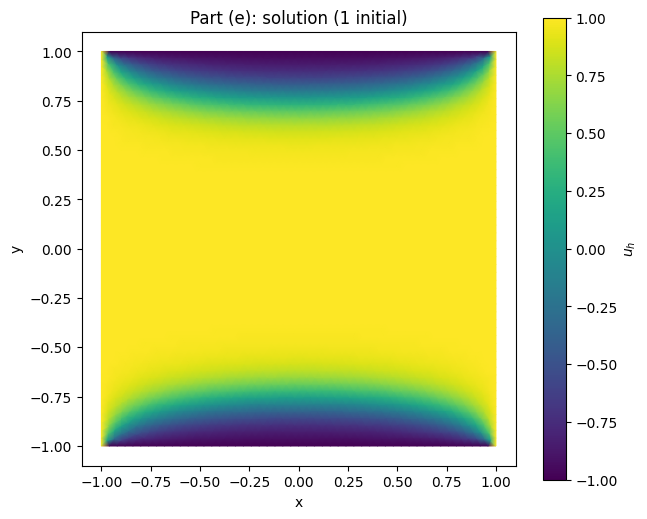

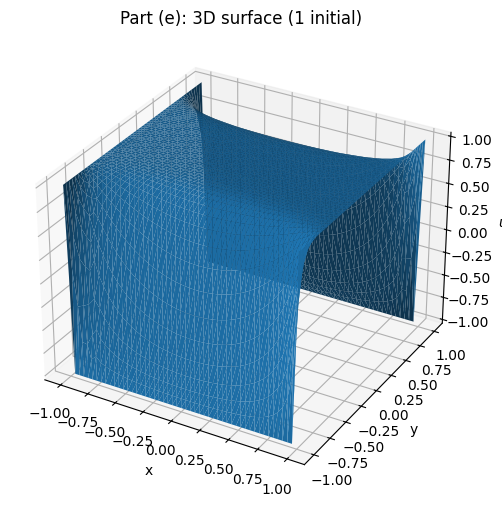

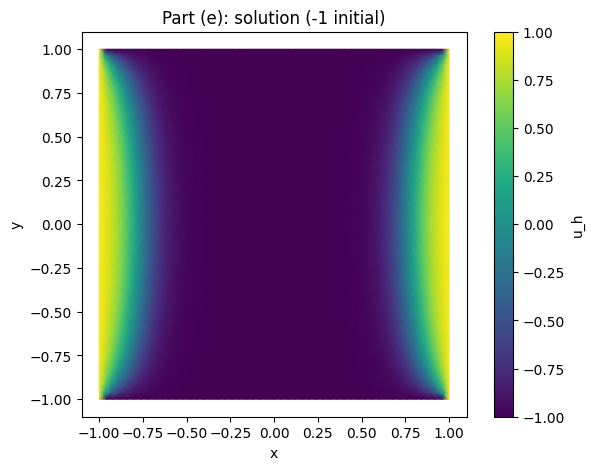

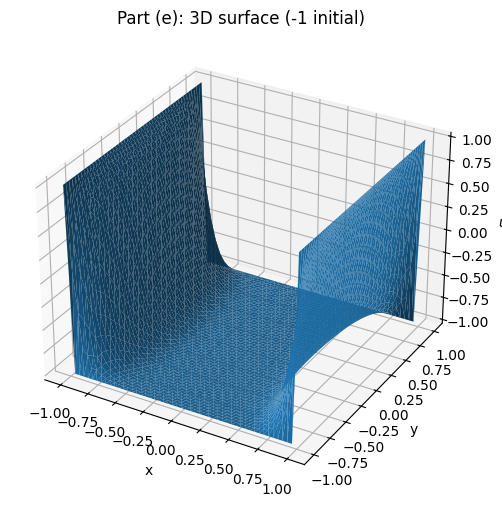

In [6]:
import numpy as np
import pygmsh
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve



eps = 0.01

with pygmsh.geo.Geometry() as geom:
    geom.add_rectangle(
        xmin=-1.0, xmax=1.0,
        ymin=-1.0, ymax=1.0,
        z=0.0,
        mesh_size=0.04
    )
    mesh = geom.generate_mesh()

points = mesh.points[:, :2]
triangles = mesh.cells_dict["triangle"]

n_nodes = len(points)
n_tri = len(triangles)



def triangle_area(coords):
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]
    return 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))


def local_stiffness(coords, eps):

    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]

    A = triangle_area(coords)

    b = np.array([y2 - y3, y3 - y1, y1 - y2], dtype=float)
    c = np.array([x3 - x2, x1 - x3, x2 - x1], dtype=float)

    Ke = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            Ke[i, j] = eps * (b[i]*b[j] + c[i]*c[j]) / (4.0 * A)

    return Ke


def local_basis_at_cen():
    return np.array([1/3, 1/3, 1/3], dtype=float)


def local_residual(coords, u_local, eps):

    A = triangle_area(coords)
    Ke = local_stiffness(coords, eps)

    Re = Ke @ u_local

    phi = local_basis_at_cen()
    u_c = np.dot(phi, u_local)
    Re += -(u_c - u_c**3) * (A / 3.0) * np.ones(3)

    return Re


def local_jacobian(coords, u_local, eps):

    A = triangle_area(coords)
    Ke = local_stiffness(coords, eps)

    phi = local_basis_at_cen()
    u_c = np.dot(phi, u_local)

    Je = Ke.copy()

    factor = -(1.0 - 3.0 * u_c**2)

    for i in range(3):
        for j in range(3):
            Je[i, j] += factor * phi[i] * phi[j] * A

    return Je

tol = 1e-12

bdry_nodes = np.where(
    (np.abs(points[:, 0] + 1.0) < tol) |
    (np.abs(points[:, 0] - 1.0) < tol) |
    (np.abs(points[:, 1] + 1.0) < tol) |
    (np.abs(points[:, 1] - 1.0) < tol)
)[0]

interior_nodes = np.setdiff1d(np.arange(n_nodes), bdry_nodes)

def uD_zero(points):
    return np.zeros(len(points))


def uD_frustrated(points, tol=1e-12):

    x = points[:, 0]
    y = points[:, 1]

    vals = np.zeros(len(points))

    left_right = (np.abs(x + 1.0) < tol) | (np.abs(x - 1.0) < tol)
    top_bottom = (np.abs(y + 1.0) < tol) | (np.abs(y - 1.0) < tol)

    vals[left_right] = 1.0
    vals[top_bottom & (~left_right)] = -1.0

    return vals


def assemble(points, triangles, u, eps):
    R = np.zeros(n_nodes)
    J = lil_matrix((n_nodes, n_nodes))

    for tri in triangles:
        coords = points[tri]
        u_local = u[tri]

        Re = local_residual(coords, u_local, eps)
        Je = local_jacobian(coords, u_local, eps)

        for a in range(3):
            Aidx = tri[a]
            R[Aidx] += Re[a]
            for b in range(3):
                Bidx = tri[b]
                J[Aidx, Bidx] += Je[a, b]

    return R, J.tocsr()


def solve_landau(points, triangles, eps, u_boundary, u0,
                          tol_newton=1e-10, max_iter=40):
    u = u0.copy()
    u[bdry_nodes] = u_boundary[bdry_nodes]

    for k in range(max_iter):
        R, J = assemble(points, triangles, u, eps)

        Ri = R[interior_nodes]
        Jii = J[interior_nodes][:, interior_nodes]

        w = np.zeros(n_nodes)
        w[interior_nodes] = spsolve(Jii, Ri)

        u_new = u - w
        u_new[bdry_nodes] = u_boundary[bdry_nodes]

        error = np.max(np.abs(w[interior_nodes]))
        u = u_new

        if error < tol_newton:
            break

    return u


triang = mtri.Triangulation(points[:, 0], points[:, 1], triangles)

plt.figure(figsize=(7, 6))
plt.triplot(triang, color="black", linewidth=0.7)
plt.gca().set_aspect("equal")
plt.title("pygmsh mesh on [-1,1] x [-1,1] domain")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("mesh_squre.svg")
plt.show()


u_boundary_d = uD_zero(points)

u0_d = -np.ones(n_nodes)
u0_d[bdry_nodes] = u_boundary_d[bdry_nodes]

u_d = solve_landau(points, triangles, eps, u_boundary_d, u0_d)

plt.figure(figsize=(7, 6))
plt.tripcolor(triang, u_d, shading="gouraud")
plt.colorbar(label=r"$u_h$")
plt.gca().set_aspect("equal")
plt.title(r"Part (d): solution with $u_D = 0$")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("original_from_ref.png", dpi=400)
plt.show()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(points[:, 0], points[:, 1], u_d, triangles=triangles)
ax.set_title("Part (d): 3D surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r"$u$")
plt.savefig("original_from_ref3d.png", dpi=400)
plt.show()



u_boundary_e = uD_frustrated(points)

u0_plus = np.ones(n_nodes)
u0_plus[bdry_nodes] = u_boundary_e[bdry_nodes]

u_plus = solve_landau(points, triangles, eps, u_boundary_e, u0_plus)

plt.figure(figsize=(7, 6))
plt.tripcolor(triang, u_plus, shading="gouraud")
plt.colorbar(label=r"$u_h$")
plt.gca().set_aspect("equal")
plt.title("Part (e): solution (1 initial)")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("parte_heat.png", dpi=400)
plt.show()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(points[:, 0], points[:, 1], u_plus, triangles=triangles)
ax.set_title("Part (e): 3D surface (1 initial)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r"$u$")
plt.savefig("parte_3e.png", dpi=400)
plt.show()


u0_minus = -np.ones(n_nodes)
u0_minus[bdry_nodes] = u_boundary_e[bdry_nodes]

u_minus = solve_landau(points, triangles, eps, u_boundary_e, u0_minus)

plt.figure(figsize=(7, 5))
plt.tripcolor(triang, u_minus, shading="gouraud")
plt.colorbar(label="u_h")
plt.gca().set_aspect("equal")
plt.title("Part (e): solution (-1 initial)")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("parte_heat_minus1.png", dpi=400)
plt.show()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(points[:, 0], points[:, 1], u_minus, triangles=triangles)
ax.set_title("Part (e): 3D surface (-1 initial)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r"$u$")
plt.savefig("parte_3d_minus1.png", dpi=400)
plt.show()